In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_excel(r'C:\Users\abdin\Desktop\Decision Analysist\Chapter 1 Projects\East African Countries Development Indicators\Data\EAC_Development_Indicator.xlsx')

In [3]:
df.head(10)

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,"Somalia, Fed. Rep.",SOM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..
1,"Somalia, Fed. Rep.",SOM,GDP per capita (current LCU),NY.GDP.PCAP.CN,6854386.7667,7051973.88687,7886498.16749,7586221.927288,8687389.532599,9917534.213918,10631251.105358,11801599.049443,12204589.406223,13533773.084612,13348437.043332,14296900.577028,15378821.794104,16250405.979972,17701267.753094,..
2,"Somalia, Fed. Rep.",SOM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,..,..,..,18.828,..,..,11.086,..,..,..
3,"Somalia, Fed. Rep.",SOM,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,..,..,149.468846,146.105261,143.375254,142.736195,142.089647,142.582647,145.395656,144.165896,148.388966,146.788991,155.395472,159.244388,167.903401,..
4,"Somalia, Fed. Rep.",SOM,"Population, total",SP.POP.TOTL,12261756,12348830,12461160,12869594,13339491,13806963,14348740,14916629,15452487,16030971,16651191,17271431,17801897,18358615,19009151,..
5,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,3.961389,14.022491,9.37777,5.717494,6.878155,6.582154,6.29725,8.00565,4.689806,5.239638,5.405162,6.107936,7.659863,7.671396,4.489789,..
6,Kenya,KEN,GDP per capita (current LCU),NY.GDP.PCAP.CN,86484.469525,97349.481311,108620.991794,118064.033507,130372.361863,146199.458441,157750.589446,172434.577619,186035.554688,199944.565561,205201.399214,226002.451823,248645.715814,271663.911256,287500.116953,..
7,Kenya,KEN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,2.757,..,..,5.014,..,5.585,5.441,..,..,..
8,Kenya,KEN,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,107.042692,110.582211,109.666258,110.744557,112.76126,110.346836,108.365526,110.911536,108.827584,108.935294,108.568614,108.034255,106.955211,105.301588,105.556678,..
9,Kenya,KEN,"Population, total",SP.POP.TOTL,41598567,42758461,43888303,44986791,46051440,47088526,48139687,49197766,50207107,51202827,52217334,53219166,54252461,55339003,56432944,..


In [4]:
df.shape

(45, 20)

In [5]:
df.dtypes

Country Name     object
Country Code     object
Series Name      object
Series Code      object
2010 [YR2010]    object
2011 [YR2011]    object
2012 [YR2012]    object
2013 [YR2013]    object
2014 [YR2014]    object
2015 [YR2015]    object
2016 [YR2016]    object
2017 [YR2017]    object
2018 [YR2018]    object
2019 [YR2019]    object
2020 [YR2020]    object
2021 [YR2021]    object
2022 [YR2022]    object
2023 [YR2023]    object
2024 [YR2024]    object
2025 [YR2025]    object
dtype: object

In [6]:
df.isnull().sum()

Country Name     3
Country Code     5
Series Name      5
Series Code      5
2010 [YR2010]    5
2011 [YR2011]    5
2012 [YR2012]    5
2013 [YR2013]    5
2014 [YR2014]    5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
2022 [YR2022]    5
2023 [YR2023]    5
2024 [YR2024]    5
2025 [YR2025]    5
dtype: int64

In [7]:
(df["Country Name"].unique())

array(['Somalia, Fed. Rep.', 'Kenya', 'Uganda', 'South Sudan', 'Rwanda',
       'Congo, Dem. Rep.', 'Tanzania', 'Burundi', nan,
       'Data from database: World Development Indicators',
       'Last Updated: 04/08/2026'], dtype=object)

In [8]:
df["Series Name"].unique()

array(['Inflation, consumer prices (annual %)',
       'GDP per capita (current LCU)',
       'Unemployment, total (% of total labor force) (national estimate)',
       'Gross national expenditure (% of GDP)', 'Population, total', nan],
      dtype=object)

## Data Diagnosis — EAC World Development Indicators

**Source:** World Bank WDI, Downloaded April 2026  
**Shape:** 45 rows × 20 columns  
**Countries:** 8 (Somalia, Kenya, Uganda, South Sudan, Rwanda, DRC, Tanzania, Burundi)  
**Indicators:** 5 per country  

**Problems Identified:**

1. MISSING VALUE ENCODING: World Bank uses `..` for missing data.
   Python does not recognize this as NaN. All year columns are misread 
   as object/text instead of numeric.

2. METADATA CONTAMINATION: Excel footer rows were imported as data.
   'Data from database' and 'Last Updated' appear as fake country names.

3. DTYPE CORRUPTION: All 16 year columns show dtype=object.
   No numeric operations are possible until this is fixed.

4. DIRTY COLUMN NAMES: Year columns named '2010 [YR2010]' instead of '2010'.
   Must be renamed for time series work.

5. WRONG STRUCTURE: Data is in wide format (years as columns).
   Must be reshaped to long format (one row per country-indicator-year).

**Decision Risk if Used Uncleaned:**
Any calculation on this data would silently fail or produce wrong results
because numeric columns are stored as text.

In [9]:
# Check the problem rows first
df[df["Country Name"].isin([
    "Data from database: World Development Indicators",
    "Last Updated: 04/08/2026"
])]

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
43,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,Last Updated: 04/08/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Keep only real countries
valid_countries = [
    "Somalia, Fed. Rep.", "Kenya", "Uganda", 
    "South Sudan", "Rwanda", "Congo, Dem. Rep.", 
    "Tanzania", "Burundi"
]

df = df[df["Country Name"].isin(valid_countries)]
df = df.dropna(subset=["Country Name"])

# Confirm shape
df.shape

(40, 20)

In [11]:
# Replace .. with real NaN
df = df.replace("..", np.nan)
# Confirm the dtype is still object before conversion
df.dtypes

C:\Users\abdin\AppData\Local\Temp\ipykernel_3088\2660266352.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("..", np.nan)


Country Name      object
Country Code      object
Series Name       object
Series Code       object
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
2025 [YR2025]    float64
dtype: object

In [12]:
# Now identify year columns and convert them to numeric
year_cols = [col for col in df.columns if "YR" in col]

df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")

# Confirm dtypes changed
df.dtypes

Country Name      object
Country Code      object
Series Name       object
Series Code       object
2010 [YR2010]    float64
2011 [YR2011]    float64
2012 [YR2012]    float64
2013 [YR2013]    float64
2014 [YR2014]    float64
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
2025 [YR2025]    float64
dtype: object

In [13]:
# Now check how many real NaN values we have
df.isnull().sum()

Country Name      0
Country Code      0
Series Name       0
Series Code       0
2010 [YR2010]     9
2011 [YR2011]     9
2012 [YR2012]     6
2013 [YR2013]     8
2014 [YR2014]     6
2015 [YR2015]    10
2016 [YR2016]    10
2017 [YR2017]    11
2018 [YR2018]    12
2019 [YR2019]     9
2020 [YR2020]     9
2021 [YR2021]    10
2022 [YR2022]    10
2023 [YR2023]    12
2024 [YR2024]    11
2025 [YR2025]    40
dtype: int64

In [14]:
df.columns = [col.split(" ")[0] if "YR" in col else col for col in df.columns]

df.columns.tolist()

['Country Name',
 'Country Code',
 'Series Name',
 'Series Code',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

In [15]:
df = df.drop(columns= ["2025"])

In [16]:
df.shape

(40, 19)

In [17]:
year_cols = [str(y) for y in range(2010, 2025)]

df_long = pd.melt(
    df,
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long.shape

(600, 6)

In [18]:
df_long.head(10)

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,"Somalia, Fed. Rep.",SOM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,NaN
1,"Somalia, Fed. Rep.",SOM,GDP per capita (current LCU),NY.GDP.PCAP.CN,2010,6.854387e+06
2,"Somalia, Fed. Rep.",SOM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,2010,NaN
3,"Somalia, Fed. Rep.",SOM,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,2010,NaN
4,"Somalia, Fed. Rep.",SOM,"Population, total",SP.POP.TOTL,2010,1.226176e+07
5,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,3.961389e+00
6,Kenya,KEN,GDP per capita (current LCU),NY.GDP.PCAP.CN,2010,8.648447e+04
7,Kenya,KEN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,2010,NaN
8,Kenya,KEN,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,2010,1.070427e+02
9,Kenya,KEN,"Population, total",SP.POP.TOTL,2010,4.159857e+07


In [19]:
df_long.to_csv("EAC_Development_Indicators_Clean.csv", index=False)

In [20]:
df_long.to_csv(
    r'C:\Users\abdin\Desktop\Decision Analysist\Chapter 1 Projects\East African Countries Development Indicators\Data\EAC_Development_Indicators_Clean.csv',
    index=False
)

In [21]:
df_somalia = df_long[df_long["Country Name"] == "Somalia, Fed. Rep."]
df_somalia.head(20)

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,"Somalia, Fed. Rep.",SOM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,NaN
1,"Somalia, Fed. Rep.",SOM,GDP per capita (current LCU),NY.GDP.PCAP.CN,2010,6.854387e+06
2,"Somalia, Fed. Rep.",SOM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,2010,NaN
3,"Somalia, Fed. Rep.",SOM,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,2010,NaN
4,"Somalia, Fed. Rep.",SOM,"Population, total",SP.POP.TOTL,2010,1.226176e+07
40,"Somalia, Fed. Rep.",SOM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2011,NaN
41,"Somalia, Fed. Rep.",SOM,GDP per capita (current LCU),NY.GDP.PCAP.CN,2011,7.051974e+06
42,"Somalia, Fed. Rep.",SOM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,2011,NaN
43,"Somalia, Fed. Rep.",SOM,Gross national expenditure (% of GDP),NE.DAB.TOTL.ZS,2011,NaN
44,"Somalia, Fed. Rep.",SOM,"Population, total",SP.POP.TOTL,2011,1.234883e+07


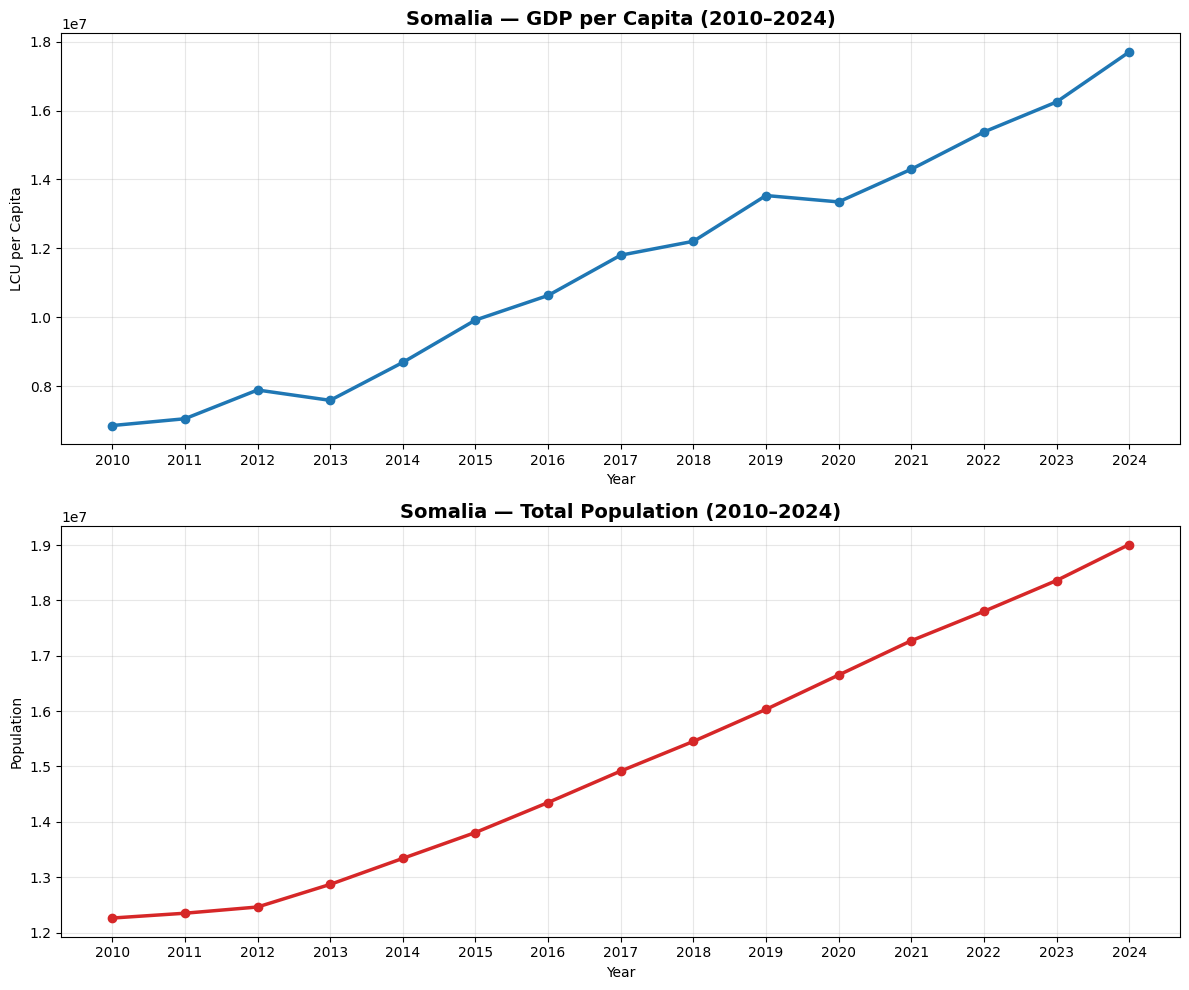

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# GDP per capita - Somalia
somalia_gdp = df_somalia[df_somalia["Series Name"] == "GDP per capita (current LCU)"]
axes[0].plot(somalia_gdp["Year"], somalia_gdp["Value"], 
             color="#1f77b4", linewidth=2.5, marker="o")
axes[0].set_title("Somalia — GDP per Capita (2010–2024)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("LCU per Capita")
axes[0].grid(True, alpha=0.3)

# Population - Somalia
somalia_pop = df_somalia[df_somalia["Series Name"] == "Population, total"]
axes[1].plot(somalia_pop["Year"], somalia_pop["Value"], 
             color="#d62728", linewidth=2.5, marker="o")
axes[1].set_title("Somalia — Total Population (2010–2024)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Population")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\abdin\Desktop\Decision Analysist\Chapter 1 Projects\East African Countries Development Indicators\somalia_analysis.png', 
            dpi=150, bbox_inches="tight")
plt.show()

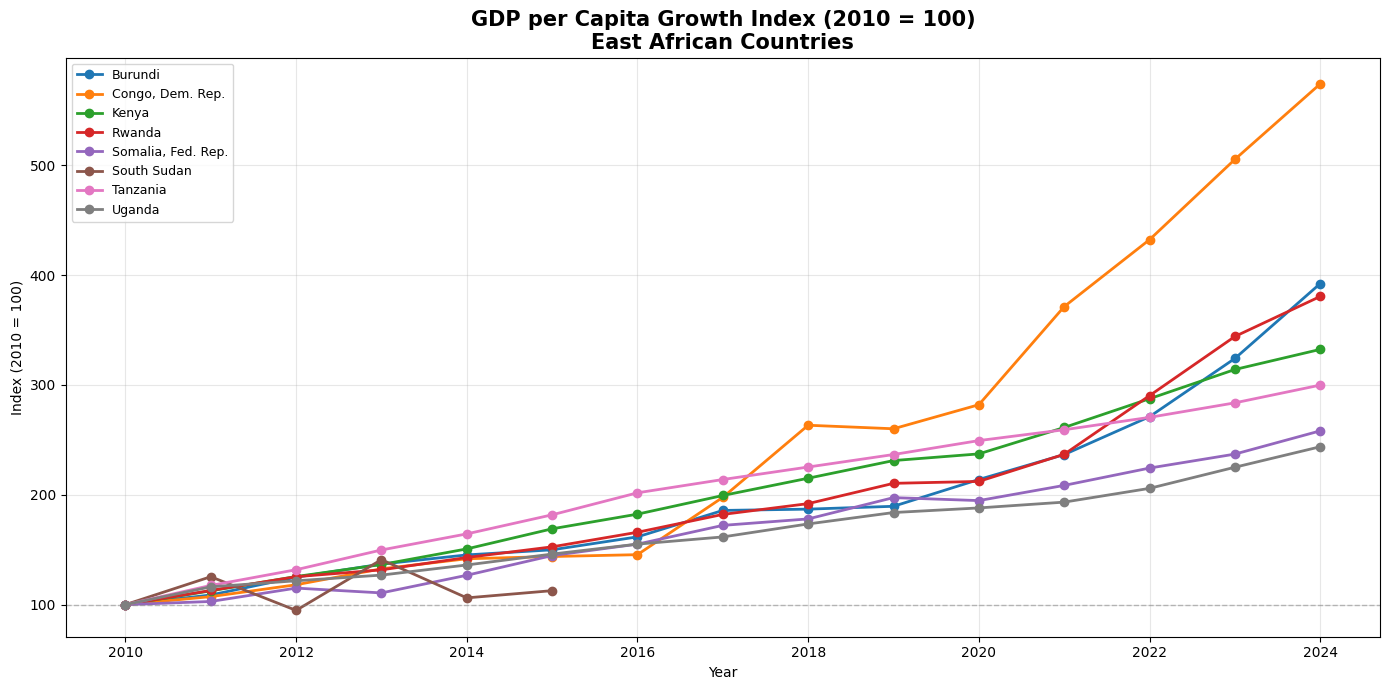

In [26]:
# Step 1 - Filter GDP per capita for all countries
gdp = df_long[df_long["Series Name"] == "GDP per capita (current LCU)"].copy()

# Step 2 - Index to 2010 = 100 for each country
gdp["Year"] = gdp["Year"].astype(int)
base = gdp[gdp["Year"] == 2010].set_index("Country Name")["Value"]
gdp["Indexed"] = gdp.apply(lambda row: (row["Value"] / base[row["Country Name"]]) * 100, axis=1)

# Step 3 - Plot
fig, ax = plt.subplots(figsize=(14, 7))

for country, group in gdp.groupby("Country Name"):
    ax.plot(group["Year"], group["Indexed"], marker="o", linewidth=2, label=country)

ax.axhline(100, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("GDP per Capita Growth Index (2010 = 100)\nEast African Countries", 
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2010 = 100)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\abdin\Desktop\Decision Analysist\Chapter 1 Projects\East African Countries Development Indicators\gdp_comparison.png',
            dpi=150, bbox_inches="tight")
plt.show()

In [25]:
df_long[
    (df_long["Country Name"] == "Congo, Dem. Rep.") & 
    (df_long["Series Name"] == "Inflation, consumer prices (annual %)")
].sort_values("Year")

,Country Name,Country Code,Series Name,Series Code,Year,Value
25,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2010,7.100000
65,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2011,15.316516
105,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2012,9.721828
145,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2013,0.808223
185,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2014,1.243039
225,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2015,0.744199
265,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2016,2.885851
305,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2017,NaN
345,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2018,NaN
385,"Congo, Dem. Rep.",COD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2019,NaN
